In [ ]:
# --- portable setup (added 2026-09-12 when the project moved to GitHub) ---------------------
# All paths below resolve from HME_ROOT, the repository root.  On Colab: mount Drive and point
# HME_ROOT at your clone.  Locally: run jupyter from the repo, or export HME_ROOT=/path/to/repo.
import os
try:
    from google.colab import drive; drive.mount('/content/drive')
    HME_ROOT = os.environ.get('HME_ROOT', '/content/drive/MyDrive/hyperbolic-icd10')   # <-- edit
except ImportError:
    HME_ROOT = os.environ.get('HME_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
assert os.path.isdir(os.path.join(HME_ROOT, 'data')), f'HME_ROOT={HME_ROOT!r} is not the repo root'
print('HME_ROOT =', HME_ROOT)


#Phase 1: Data Processing and Setup

Mounted at /content/drive


## Setup: ALREADY DONE — Skip these cells in future sessions

In [28]:
import os

# Project root in Drive
PROJECT_ROOT = HME_ROOT

# Subdirectories
SUBDIRS = ['data', 'data/raw', 'data/processed', 'code', 'models', 'results', 'notebooks']

for subdir in SUBDIRS:
    full_path = os.path.join(PROJECT_ROOT, subdir)
    os.makedirs(full_path, exist_ok=True)
    print(f"Ready: {full_path}")

DATA_RAW = os.path.join(PROJECT_ROOT, 'data', 'raw')
print(f"\nRaw data will go to: {DATA_RAW}")

Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/processed
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/code
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/models
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/results
Ready: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding

In [29]:
import requests
import os

# This is the FY2025 ICD-10-CM Code Tables and Index file
# If this URL fails, go to https://www.cms.gov/medicare/coding-billing/icd-10-codes
# and search for "Code Tables, Tabular and Index"
ICD10_URL = "https://www.cms.gov/files/zip/2025-code-tables-tabular-and-index.zip"

OUTPUT_PATH = os.path.join(DATA_RAW, 'icd10cm_2025_code_tables.zip')

def download_with_progress(url, output_path):
    """Download a file with progress reporting."""
    print(f"Downloading from: {url}")
    print(f"Saving to: {output_path}")

    response = requests.get(url, stream=True, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()

    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0
    chunk_size = 8192

    with open(output_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total_size > 0:
                    percent = 100 * downloaded / total_size
                    print(f"\rProgress: {percent:.1f}% ({downloaded/1e6:.1f} MB / {total_size/1e6:.1f} MB)", end='')

    print(f"\nDownload complete: {os.path.getsize(output_path) / 1e6:.1f} MB")

try:
    download_with_progress(ICD10_URL, OUTPUT_PATH)
except requests.HTTPError as e:
    print(f"\n\nDownload failed with HTTP error: {e}")
    print("The URL may have moved. Visit https://www.cms.gov/medicare/coding-billing/icd-10-codes")
    print("Look for the most recent 'Code Tables, Tabular and Index' download.")
except Exception as e:
    print(f"\n\nDownload failed: {e}")

Saving to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_2025_code_tables.zip
Progress: 100.0% (22.8 MB / 22.8 MB)
Download complete: 22.8 MB


In [30]:
import zipfile

# Verify file exists and has reasonable size
file_size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"File size: {file_size_mb:.2f} MB")

if file_size_mb < 1:
    print("WARNING: file seems too small. Download may have failed silently.")
elif file_size_mb > 100:
    print("WARNING: file seems too large. Wrong file?")
else:
    print("Size looks reasonable.")

# Peek inside the zip
with zipfile.ZipFile(OUTPUT_PATH, 'r') as z:
    contents = z.namelist()
    print(f"\nFiles inside the zip ({len(contents)} total):")
    for name in contents[:20]:
        print(f"  {name}")
    if len(contents) > 20:
        print(f"  ... and {len(contents) - 20} more")

File size: 22.81 MB
Size looks reasonable.

Files inside the zip (13 total):
  icd10cm_drug_2025.pdf
  icd10cm_drug_2025.xml
  icd10cm_drug_neoplasm.xsd
  icd10cm_eindex_2025.pdf
  icd10cm_eindex_2025.xml
  icd10cm_index.xsd
  icd10cm_index_2025.pdf
  icd10cm_index_2025.xml
  icd10cm_neoplasm_2025.pdf
  icd10cm_neoplasm_2025.xml
  icd10cm_tabular.xsd
  icd10cm_tabular_2025.pdf
  icd10cm_tabular_2025.xml


In [31]:
EXTRACT_DIR = os.path.join(DATA_RAW, 'icd10cm_extracted')
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(OUTPUT_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
    print(f"Extracted to: {EXTRACT_DIR}")

# List what we extracted
extracted_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        full = os.path.join(root, f)
        size_mb = os.path.getsize(full) / 1e6
        extracted_files.append((f, full, size_mb))

extracted_files.sort(key=lambda x: -x[2])
print("\nFiles by size:")
for name, path, size in extracted_files[:10]:
    print(f"  {size:.2f} MB  {name}")

Extracted to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_extracted

Files by size:
  43.85 MB  icd10cm_index_2025.pdf
  30.99 MB  icd10cm_tabular_2025.pdf
  14.05 MB  icd10cm_drug_2025.pdf
  9.66 MB  icd10cm_tabular_2025.xml
  9.63 MB  icd10cm_index_2025.xml
  4.28 MB  icd10cm_eindex_2025.pdf
  3.65 MB  icd10cm_neoplasm_2025.pdf
  2.12 MB  icd10cm_drug_2025.xml
  1.05 MB  icd10cm_eindex_2025.xml
  0.58 MB  icd10cm_neoplasm_2025.xml


In [32]:
import xml.etree.ElementTree as ET

# Find the tabular XML file (it's the main one we care about)
TABULAR_XML = None
for name, path, size in extracted_files:
    if 'tabular' in name.lower() and name.endswith('.xml'):
        TABULAR_XML = path
        break

if TABULAR_XML is None:
    print("Could not find tabular XML file. List of extracted files:")
    for name, path, size in extracted_files:
        print(f"  {name}")
else:
    print(f"Tabular XML: {TABULAR_XML}")

    # Just peek at the structure — don't try to parse the whole thing yet
    tree = ET.parse(TABULAR_XML)
    root = tree.getroot()
    print(f"\nRoot element: <{root.tag}>")
    print(f"Number of top-level children: {len(root)}")
    print(f"\nFirst few child tags:")
    for child in list(root)[:10]:
        print(f"  <{child.tag}>")

Tabular XML: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_extracted/icd10cm_tabular_2025.xml

Root element: <ICD10CM.tabular>
Number of top-level children: 24

First few child tags:
  <version>
  <introduction>
  <chapter>
  <chapter>
  <chapter>
  <chapter>
  <chapter>
  <chapter>
  <chapter>
  <chapter>


In [33]:
import json
from datetime import datetime

manifest = {
    'date_downloaded': datetime.now().isoformat(),
    'icd10_zip': OUTPUT_PATH,
    'icd10_zip_size_mb': os.path.getsize(OUTPUT_PATH) / 1e6,
    'extract_dir': EXTRACT_DIR,
    'tabular_xml': TABULAR_XML,
    'tabular_xml_size_mb': os.path.getsize(TABULAR_XML) / 1e6 if TABULAR_XML else None,
    'source_url': ICD10_URL,
}

manifest_path = os.path.join(PROJECT_ROOT, 'data', 'data_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"Manifest saved to: {manifest_path}")
print("\nContents:")
print(json.dumps(manifest, indent=2))

Manifest saved to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/data_manifest.json

Contents:
{
  "date_downloaded": "2026-05-13T18:14:47.741014",
  "icd10_zip": "/content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_2025_code_tables.zip",
  "icd10_zip_size_mb": 22.809189,
  "extract_dir": "/content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_extracted",
  "tabular_xml": "/content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_extracted/icd10cm_tabular_2025.xml",
  "tabular_xml_size_mb": 9.657316,
  "source_url": "https://www.cms.gov/files/zip/2025-code-tables-tabular-and-index.zip"
}


## Parsing and feature extraction: ALREADY DONE — Skip these cells in future sessions

In [34]:
import xml.etree.ElementTree as ET
import json
import os
from collections import defaultdict

# Path to the tabular XML (from your manifest)
TABULAR_XML = HME_ROOT + '/data/raw/icd10cm_extracted/icd10cm_tabular_2025.xml'

# Load the XML
print("Parsing XML (takes ~10 seconds)...")
tree = ET.parse(TABULAR_XML)
root = tree.getroot()
print(f"Root element: <{root.tag}>")

# Storage for parsed data
nodes = {}      # code -> dict of metadata
edges = []      # list of (parent_code, child_code) tuples
chapter_map = {}  # code -> chapter number (for later analysis)

# Add a synthetic root for the whole ontology
ROOT_CODE = 'ROOT'
nodes[ROOT_CODE] = {
    'code': ROOT_CODE,
    'description': 'ICD-10-CM root',
    'type': 'root',
    'chapter': None,
    'depth': 0,
}

def get_text(element, tag):
    """Safely extract text from a subelement, return None if missing."""
    sub = element.find(tag)
    if sub is not None and sub.text is not None:
        return sub.text.strip()
    return None

def walk_diag(diag_element, parent_code, chapter_num, depth):
    """Recursively walk diagnosis elements, adding nodes and edges."""
    code = get_text(diag_element, 'name')
    desc = get_text(diag_element, 'desc')

    if code is None:
        return  # malformed entry, skip

    # Add this node
    nodes[code] = {
        'code': code,
        'description': desc,
        'type': 'diagnosis',
        'chapter': chapter_num,
        'depth': depth,
    }
    chapter_map[code] = chapter_num

    # Add edge from parent to this node
    edges.append((parent_code, code))

    # Recurse into nested diag elements
    for child_diag in diag_element.findall('diag'):
        walk_diag(child_diag, code, chapter_num, depth + 1)

# Walk all chapters
chapter_count = 0
for chapter in root.findall('chapter'):
    chapter_count += 1
    chapter_num = get_text(chapter, 'name')
    chapter_desc = get_text(chapter, 'desc')

    chapter_code = f'CH{chapter_num}'
    nodes[chapter_code] = {
        'code': chapter_code,
        'description': chapter_desc,
        'type': 'chapter',
        'chapter': chapter_num,
        'depth': 1,
    }
    edges.append((ROOT_CODE, chapter_code))

    # Walk sections within the chapter
    for section in chapter.findall('section'):
        section_id = section.get('id')  # e.g. "I30-I52"
        section_desc = get_text(section, 'desc')

        if section_id is None:
            continue

        section_code = f'SEC_{section_id}'
        nodes[section_code] = {
            'code': section_code,
            'description': section_desc,
            'type': 'section',
            'chapter': chapter_num,
            'depth': 2,
        }
        edges.append((chapter_code, section_code))

        # Walk diagnoses within the section
        for diag in section.findall('diag'):
            walk_diag(diag, section_code, chapter_num, depth=3)

print(f"\nParse complete.")
print(f"Chapters processed: {chapter_count}")
print(f"Total nodes: {len(nodes)}")
print(f"Total edges: {len(edges)}")

# Breakdown by type
type_counts = defaultdict(int)
for n in nodes.values():
    type_counts[n['type']] += 1
print(f"\nBreakdown by node type:")
for t, c in sorted(type_counts.items()):
    print(f"  {t}: {c}")

# Depth distribution
depth_counts = defaultdict(int)
for n in nodes.values():
    depth_counts[n['depth']] += 1
print(f"\nBreakdown by depth:")
for d in sorted(depth_counts):
    print(f"  depth {d}: {depth_counts[d]}")

Parsing XML (takes ~10 seconds)...
Root element: <ICD10CM.tabular>

Parse complete.
Chapters processed: 22
Total nodes: 46817
Total edges: 46816

Breakdown by node type:
  chapter: 22
  diagnosis: 46498
  root: 1
  section: 296

Breakdown by depth:
  depth 0: 1
  depth 1: 22
  depth 2: 296
  depth 3: 1917
  depth 4: 10070
  depth 5: 14483
  depth 6: 19936
  depth 7: 92


In [35]:
import pickle

PROCESSED_DIR = HME_ROOT + '/data/processed'

# Save nodes and edges as pickle (fast Python format)
parsed_data = {
    'nodes': nodes,
    'edges': edges,
    'chapter_map': chapter_map,
    'metadata': {
        'source_xml': TABULAR_XML,
        'total_nodes': len(nodes),
        'total_edges': len(edges),
        'depth_max': max(n['depth'] for n in nodes.values()),
    }
}

pickle_path = os.path.join(PROCESSED_DIR, 'icd10_tree.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(parsed_data, f)

print(f"Saved to: {pickle_path}")
print(f"File size: {os.path.getsize(pickle_path) / 1e6:.2f} MB")

Saved to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/processed/icd10_tree.pkl
File size: 5.31 MB


In [36]:
import numpy as np
from collections import defaultdict

# Build parent -> children map
children_of = defaultdict(list)
for parent, child in edges:
    children_of[parent].append(child)

# Branching factor at each node
branching_factors = {}
for node_code in nodes:
    branching_factors[node_code] = len(children_of[node_code])

# Overall statistics
bfs = np.array(list(branching_factors.values()))
internal_bfs = bfs[bfs > 0]  # only count internal nodes; leaves have b=0

print("Overall branching factor statistics:")
print(f"  Total nodes: {len(bfs)}")
print(f"  Leaf nodes (b=0): {(bfs == 0).sum()}")
print(f"  Internal nodes (b>0): {(bfs > 0).sum()}")
print(f"\n  Among internal nodes:")
print(f"    Mean branching factor: {internal_bfs.mean():.2f}")
print(f"    Median branching factor: {np.median(internal_bfs):.0f}")
print(f"    Max branching factor: {internal_bfs.max()}")
print(f"    Min branching factor: {internal_bfs.min()}")
print(f"    Std deviation: {internal_bfs.std():.2f}")
print(f"\n  Branching factor distribution:")
for threshold in [1, 2, 5, 10, 20, 50]:
    count = (internal_bfs > threshold).sum()
    pct = 100 * count / len(internal_bfs)
    print(f"    Nodes with b > {threshold}: {count} ({pct:.1f}%)")

Overall branching factor statistics:
  Total nodes: 46817
  Leaf nodes (b=0): 36042
  Internal nodes (b>0): 10775

  Among internal nodes:
    Mean branching factor: 4.34
    Median branching factor: 3
    Max branching factor: 34
    Min branching factor: 1
    Std deviation: 2.47

  Branching factor distribution:
    Nodes with b > 1: 10471 (97.2%)
    Nodes with b > 2: 8967 (83.2%)
    Nodes with b > 5: 2720 (25.2%)
    Nodes with b > 10: 143 (1.3%)
    Nodes with b > 20: 11 (0.1%)
    Nodes with b > 50: 0 (0.0%)


In [37]:
# Branching by chapter
chapter_stats = defaultdict(list)
for code, n in nodes.items():
    if n['type'] == 'diagnosis' and branching_factors[code] > 0:
        # only internal diagnosis nodes
        chapter_stats[n['chapter']].append(branching_factors[code])

print("\nBranching factor by chapter (internal diagnosis nodes only):")
print(f"{'Chapter':<8} {'Nodes':<8} {'Mean':<8} {'Median':<8} {'Max':<8} {'Std':<8}")
for chap in sorted(chapter_stats.keys(), key=lambda x: int(x) if x else 0):
    factors = np.array(chapter_stats[chap])
    print(f"{chap:<8} {len(factors):<8} {factors.mean():<8.2f} {np.median(factors):<8.0f} {factors.max():<8} {factors.std():<8.2f}")


Branching factor by chapter (internal diagnosis nodes only):
Chapter  Nodes    Mean     Median   Max      Std     
1        240      4.75     4        10       2.17    
2        450      4.52     3        12       2.83    
3        77       4.71     4        10       2.11    
4        226      4.02     3        10       2.15    
5        241      4.32     4        10       2.11    
6        229      3.72     3        13       2.21    
7        732      4.31     4        10       1.54    
8        218      3.89     4        10       1.38    
9        370      4.63     4        13       1.98    
10       111      3.67     3        10       2.07    
11       252      4.12     3        11       2.32    
12       188      5.31     6        12       2.44    
13       1654     4.24     3        13       2.44    
14       206      4.62     4        13       2.46    
15       410      4.19     4        18       1.84    
16       102      4.96     4        10       2.78    
17       182      5.

In [38]:
# Branching factor by section (not just chapter)
section_stats = defaultdict(list)
for code, n in nodes.items():
    if n['type'] == 'diagnosis' and branching_factors[code] > 0:
        # find which section this node belongs to by walking up the tree
        # we need a child->parent map for this
        pass  # let's build parent map first

# Build child -> parent map
parent_of = {}
for parent, child in edges:
    parent_of[child] = parent

# Walk up to find section ancestor for each diagnosis
def find_section(code):
    current = code
    while current in parent_of:
        if nodes[current]['type'] == 'section':
            return current
        current = parent_of[current]
    return None

# Group internal diagnosis nodes by their section
section_stats = defaultdict(list)
for code, n in nodes.items():
    if n['type'] == 'diagnosis' and branching_factors[code] > 0:
        section = find_section(code)
        if section:
            section_stats[section].append(branching_factors[code])

# Compute mean branching factor per section
section_means = {sec: np.mean(bfs) for sec, bfs in section_stats.items() if len(bfs) >= 3}
print(f"Sections with >=3 internal diagnosis nodes: {len(section_means)}")
print(f"\nDistribution of section-level mean branching factor:")
means_arr = np.array(list(section_means.values()))
print(f"  Min mean: {means_arr.min():.2f}")
print(f"  Max mean: {means_arr.max():.2f}")
print(f"  Median mean: {np.median(means_arr):.2f}")
print(f"  Std of section means: {means_arr.std():.2f}")
print(f"\n  Ratio max/min: {means_arr.max()/means_arr.min():.2f}x")

Sections with >=3 internal diagnosis nodes: 255

Distribution of section-level mean branching factor:
  Min mean: 2.33
  Max mean: 10.00
  Median mean: 4.25
  Std of section means: 1.10

  Ratio max/min: 4.29x


In [39]:
# Subtree size distribution - how many descendants does each node have?
# This captures "depth density" which is different from branching factor

def count_descendants(node_code, memo={}):
    if node_code in memo:
        return memo[node_code]
    count = 0
    for child in children_of[node_code]:
        count += 1 + count_descendants(child, memo)
    memo[node_code] = count
    return count

# Compute subtree size for every internal node
subtree_sizes = {}
for code in nodes:
    if branching_factors[code] > 0:
        subtree_sizes[code] = count_descendants(code)

# Statistics per chapter
print("\nSubtree size statistics by chapter:")
print(f"{'Chapter':<8} {'Mean':<10} {'Median':<10} {'Max':<10}")
chapter_subtrees = defaultdict(list)
for code, size in subtree_sizes.items():
    if nodes[code]['type'] == 'diagnosis':
        chapter_subtrees[nodes[code]['chapter']].append(size)

for chap in sorted(chapter_subtrees.keys(), key=lambda x: int(x) if x else 0):
    sizes = np.array(chapter_subtrees[chap])
    print(f"{chap:<8} {sizes.mean():<10.1f} {np.median(sizes):<10.0f} {sizes.max():<10}")


Subtree size statistics by chapter:
Chapter  Mean       Median     Max       
1        6.5        5          37        
2        7.9        3          146       
3        8.2        6          52        
4        7.4        4          64        
5        9.2        4          78        
6        6.7        4          93        
7        11.2       4          302       
8        8.8        4          93        
9        10.6       5          295       
10       5.7        3          41        
11       7.5        4          89        
12       11.2       7          207       
13       10.6       3          297       
14       8.1        4          177       
15       9.0        4          123       
16       6.7        5          31        
17       7.6        5          56        
18       7.8        5          67        
19       10.6       4          361       
20       7.5        4          246       
21       7.8        4          79        
22       1.5        2          2       

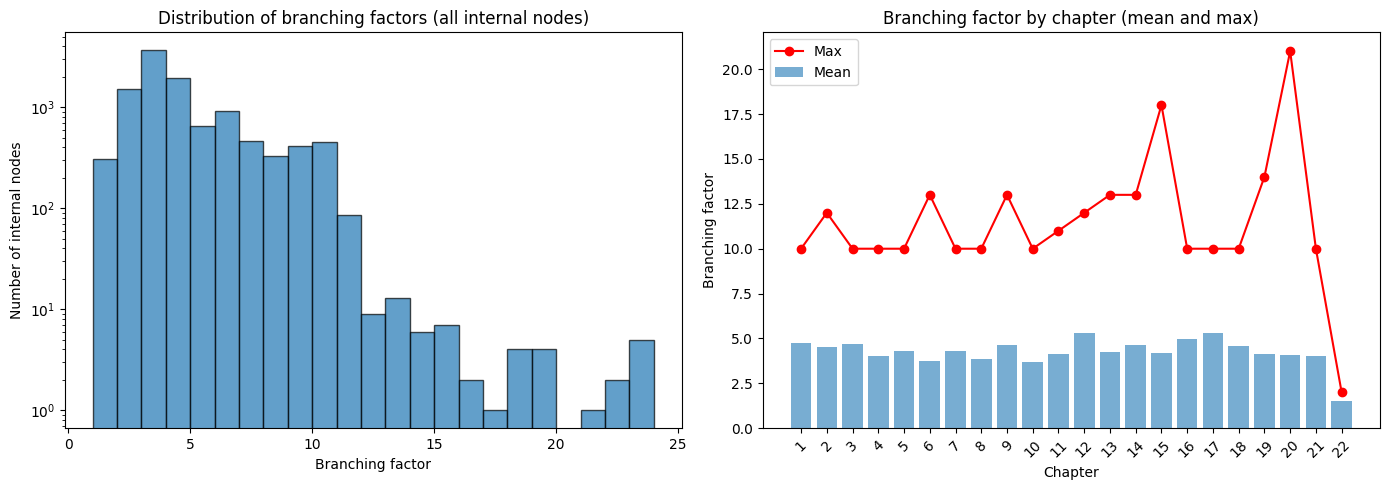

In [40]:
import matplotlib.pyplot as plt

# Histogram of all internal-node branching factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of branching factors
axes[0].hist(internal_bfs, bins=range(1, 25), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Branching factor')
axes[0].set_ylabel('Number of internal nodes')
axes[0].set_title('Distribution of branching factors (all internal nodes)')
axes[0].set_yscale('log')

# Right: per-chapter mean branching factor
chapter_nums = sorted([c for c in chapter_stats.keys() if c is not None],
                     key=lambda x: int(x) if x and x.isdigit() else 999)
chapter_means = [np.mean(chapter_stats[c]) for c in chapter_nums]
chapter_maxs = [np.max(chapter_stats[c]) for c in chapter_nums]

axes[1].bar(chapter_nums, chapter_means, alpha=0.6, label='Mean')
axes[1].plot(chapter_nums, chapter_maxs, 'ro-', label='Max')
axes[1].set_xlabel('Chapter')
axes[1].set_ylabel('Branching factor')
axes[1].set_title('Branching factor by chapter (mean and max)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(HME_ROOT + '/results/branching_distribution.png', dpi=120)
plt.show()

In [41]:
import pickle
import os
from collections import defaultdict

# Check if we already have parsed data on disk
PROCESSED_DIR = HME_ROOT + '/data/processed'
PICKLE_PATH = os.path.join(PROCESSED_DIR, 'icd10_tree.pkl')

# If we have a pickle from a previous save, load it
if os.path.exists(PICKLE_PATH):
    print(f"Loading existing pickled data from {PICKLE_PATH}")
    with open(PICKLE_PATH, 'rb') as f:
        data = pickle.load(f)
    nodes = data['nodes']
    edges = data['edges']
    print(f"Loaded {len(nodes)} nodes and {len(edges)} edges")
else:
    print(f"No pickle found at {PICKLE_PATH}")
    print("You need to re-run the XML parsing cells from earlier in the notebook.")
    print("Variables 'nodes' and 'edges' must be in memory before proceeding.")

Loading existing pickled data from /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/processed/icd10_tree.pkl
Loaded 46817 nodes and 46816 edges


In [42]:
import numpy as np
from collections import defaultdict

# Build the children-of and parent-of maps from edges
children_of = defaultdict(list)
parent_of = {}
for parent, child in edges:
    children_of[parent].append(child)
    parent_of[child] = parent

print(f"Built children-of map: {len(children_of)} nodes have children")
print(f"Built parent-of map: {len(parent_of)} nodes have a parent")

# Sanity check: only one node should have no parent (ROOT)
no_parent = [n for n in nodes if n not in parent_of]
print(f"Nodes with no parent (should be 1): {len(no_parent)}, namely {no_parent}")

Built children-of map: 10775 nodes have children
Built parent-of map: 46816 nodes have a parent
Nodes with no parent (should be 1): 1, namely ['ROOT']


In [43]:
def find_section_ancestor(code):
    """Walk up from code until we hit a section-type node, return that section's code."""
    current = code
    while current in parent_of:
        if nodes[current]['type'] == 'section':
            return current
        current = parent_of[current]
    return None  # for chapters, root, or anything above sections

# Test it on a few examples
print("Testing find_section_ancestor:")
for example_code in list(nodes.keys())[100:105]:
    section = find_section_ancestor(example_code)
    print(f"  {example_code} ({nodes[example_code]['type']}) -> section: {section}")

Testing find_section_ancestor:
  A15.4 (diagnosis) -> section: SEC_A15-A19
  A15.5 (diagnosis) -> section: SEC_A15-A19
  A15.6 (diagnosis) -> section: SEC_A15-A19
  A15.7 (diagnosis) -> section: SEC_A15-A19
  A15.8 (diagnosis) -> section: SEC_A15-A19


In [44]:
# Compute subtree size for every node with memoization
subtree_size_cache = {}

def compute_subtree_size(code):
    """Recursively count all descendants of this node."""
    if code in subtree_size_cache:
        return subtree_size_cache[code]
    count = 0
    for child in children_of[code]:
        count += 1 + compute_subtree_size(child)
    subtree_size_cache[code] = count
    return count

# Compute for all nodes
for code in nodes:
    compute_subtree_size(code)

print(f"Computed subtree size for {len(subtree_size_cache)} nodes")
print(f"ROOT subtree size: {subtree_size_cache['ROOT']} (should be {len(nodes) - 1})")

Computed subtree size for 46817 nodes
ROOT subtree size: 46816 (should be 46816)


In [45]:
features = {}

for code, node in nodes.items():
    features[code] = {
        'code': code,
        'description': node['description'],
        'type': node['type'],
        'chapter': node['chapter'],
        'section': find_section_ancestor(code),
        'depth': node['depth'],
        'branching_factor': len(children_of[code]),
        'subtree_size': subtree_size_cache[code],
        'is_leaf': len(children_of[code]) == 0,
        'is_internal': len(children_of[code]) > 0,
    }

print(f"Computed features for {len(features)} nodes")
print(f"\nExample features:")

# Show one example of each type
for node_type in ['root', 'chapter', 'section', 'diagnosis']:
    example = next((c for c, f in features.items() if f['type'] == node_type), None)
    if example:
        print(f"\n  {node_type} ({example}):")
        for k, v in features[example].items():
            if k != 'description' or v is None:
                print(f"    {k}: {v}")
            else:
                # truncate long descriptions
                desc = v[:60] + '...' if len(v) > 60 else v
                print(f"    {k}: {desc}")

Computed features for 46817 nodes

Example features:

  root (ROOT):
    code: ROOT
    description: ICD-10-CM root
    type: root
    chapter: None
    section: None
    depth: 0
    branching_factor: 22
    subtree_size: 46816
    is_leaf: False
    is_internal: True

  chapter (CH1):
    code: CH1
    description: Certain infectious and parasitic diseases (A00-B99)
    type: chapter
    chapter: 1
    section: None
    depth: 1
    branching_factor: 22
    subtree_size: 1329
    is_leaf: False
    is_internal: True

  section (SEC_A00-A09):
    code: SEC_A00-A09
    description: Intestinal infectious diseases (A00-A09)
    type: section
    chapter: 1
    section: SEC_A00-A09
    depth: 2
    branching_factor: 10
    subtree_size: 94
    is_leaf: False
    is_internal: True

  diagnosis (A00):
    code: A00
    description: Cholera
    type: diagnosis
    chapter: 1
    section: SEC_A00-A09
    depth: 3
    branching_factor: 3
    subtree_size: 3
    is_leaf: False
    is_internal: 

In [46]:
import json

complete_dataset = {
    'nodes': nodes,
    'edges': edges,
    'features': features,
    'children_of': dict(children_of),  # convert defaultdict to dict for pickling
    'parent_of': parent_of,
    'metadata': {
        'source_xml': HME_ROOT + '/data/raw/icd10cm_extracted/icd10cm_tabular_2025.xml',
        'icd10cm_version': 'FY2025',
        'total_nodes': len(nodes),
        'total_edges': len(edges),
        'total_internal_nodes': sum(1 for f in features.values() if f['is_internal']),
        'total_leaves': sum(1 for f in features.values() if f['is_leaf']),
        'max_depth': max(f['depth'] for f in features.values()),
        'max_branching': max(f['branching_factor'] for f in features.values()),
        'max_subtree_size': max(f['subtree_size'] for f in features.values()),
        'date_processed': '2026-05-12',
    }
}

# Save as pickle (compact, fast to reload)
PICKLE_PATH = os.path.join(PROCESSED_DIR, 'icd10_tree_with_features.pkl')
with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(complete_dataset, f)

print(f"Saved complete dataset to: {PICKLE_PATH}")
print(f"File size: {os.path.getsize(PICKLE_PATH) / 1e6:.2f} MB")

# Also save metadata as JSON (human-readable)
METADATA_PATH = os.path.join(PROCESSED_DIR, 'icd10_metadata.json')
with open(METADATA_PATH, 'w') as f:
    json.dump(complete_dataset['metadata'], f, indent=2)

print(f"\nMetadata also saved to: {METADATA_PATH}")
print("\nMetadata contents:")
for k, v in complete_dataset['metadata'].items():
    print(f"  {k}: {v}")

Saved complete dataset to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/processed/icd10_tree_with_features.pkl
File size: 10.06 MB

Metadata also saved to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/processed/icd10_metadata.json

Metadata contents:
  source_xml: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/data/raw/icd10cm_extracted/icd10cm_tabular_2025.xml
  icd10cm_version: FY2025
  total_nodes: 46817
  total_edges: 46816
  total_internal_nodes: 10775
  total_leaves: 36042
  max_depth: 7
  max_branching: 34
  max_subtree_size: 46816
  date_processed: 2026-05-12


## START HERE for new sessions: Load saved data

# Phase 2: Baselines

Starting Phase 2. Phase 1 outputs available via Cell 21 (load pickle).

If starting a fresh session:
1. Run Cell 1 (mount drive)
2. Run Cell 21 (load saved data)
3. Continue here.

In [3]:
# START HERE for new sessions: Load saved data
import pickle

PICKLE_PATH = HME_ROOT + '/data/processed/icd10_tree_with_features.pkl'

with open(PICKLE_PATH, 'rb') as f:
    data = pickle.load(f)

nodes = data['nodes']
edges = data['edges']
features = data['features']
children_of = data['children_of']
parent_of = data['parent_of']
metadata = data['metadata']

print(f"✓ Loaded {len(nodes)} nodes, {len(edges)} edges")
print(f"  Internal nodes: {sum(1 for f in features.values() if f['is_internal'])}")
print(f"  Leaves: {sum(1 for f in features.values() if f['is_leaf'])}")
print(f"  Max depth: {metadata['max_depth']}")
print(f"  Source: ICD-10-CM {metadata['icd10cm_version']}")

✓ Loaded 46817 nodes, 46816 edges
  Internal nodes: 10775
  Leaves: 36042
  Max depth: 7
  Source: ICD-10-CM FY2025


In [4]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU device: NVIDIA A100-SXM4-40GB
GPU memory: 42.4 GB


In [5]:
# Map each node code to an integer index
# PyTorch embeddings work with integer indices, not string codes
code_to_idx = {code: i for i, code in enumerate(sorted(nodes.keys()))}
idx_to_code = {i: code for code, i in code_to_idx.items()}
N = len(code_to_idx)

print(f"Created index for {N} nodes")
print(f"\nExample mappings:")
for code in ['ROOT', 'CH9', 'SEC_I30-I52', 'I50']:
    if code in code_to_idx:
        print(f"  '{code}' -> index {code_to_idx[code]}")

# Convert edges to integer pairs
edges_idx = [(code_to_idx[p], code_to_idx[c]) for p, c in edges]
print(f"\nConverted {len(edges_idx)} edges to integer pairs")

# Build a set of all directly-connected pairs (both directions)
# Used to exclude actual edges when picking negative samples
connected = set()
for p, c in edges_idx:
    connected.add((p, c))
    connected.add((c, p))

print(f"Connected pairs (both directions): {len(connected)}")

Created index for 46817 nodes

Example mappings:
  'ROOT' -> index 27818
  'CH9' -> index 2863
  'I50' -> index 11339

Converted 46816 edges to integer pairs
Connected pairs (both directions): 93632


In [6]:
import numpy as np

def sample_negatives(anchor_idx, num_negatives, N, connected, max_attempts=100):
    """
    Sample K random node indices that are not directly connected to the anchor.

    Parameters
    ----------
    anchor_idx : int
        The integer index of the anchor node we're sampling negatives for.
    num_negatives : int
        How many negative samples to generate (typically 10).
    N : int
        Total number of nodes in the ontology (46,817 for our ICD-10 tree).
    connected : set of (int, int) tuples
        Set of all directly-connected pairs, both directions.
        Used to exclude actual edges from negative candidates.
    max_attempts : int
        Safety limit on how many random draws we'll make before giving up.
        Set high enough that rejection is essentially never an issue.

    Returns
    -------
    negatives : list of int
        K integer indices, none equal to anchor_idx, none directly connected to anchor.
    """
    negatives = []
    attempts = 0

    while len(negatives) < num_negatives and attempts < max_attempts:
        # Draw a random candidate
        candidate = np.random.randint(0, N)
        attempts += 1

        # Skip if it's the anchor itself
        if candidate == anchor_idx:
            continue

        # Skip if it's directly connected to the anchor
        if (anchor_idx, candidate) in connected:
            continue

        # Skip if already in our list (avoid duplicates)
        if candidate in negatives:
            continue

        # Accept it
        negatives.append(candidate)

    if len(negatives) < num_negatives:
        raise RuntimeError(f"Could not find {num_negatives} valid negatives after {max_attempts} attempts")

    return negatives

In [7]:
# Test the negative sampler on a few anchors
test_anchors = ['I50', 'ROOT', 'CH9']

for anchor_code in test_anchors:
    if anchor_code not in code_to_idx:
        print(f"Skipping {anchor_code} (not in index)")
        continue

    anchor_idx = code_to_idx[anchor_code]
    negatives = sample_negatives(anchor_idx, num_negatives=10, N=N, connected=connected)

    print(f"\nAnchor: {anchor_code} (idx {anchor_idx})")
    print(f"  10 negative samples (as codes):")
    for neg_idx in negatives:
        neg_code = idx_to_code[neg_idx]
        neg_desc = nodes[neg_code]['description'][:50] if nodes[neg_code]['description'] else '(no desc)'
        print(f"    idx {neg_idx}: {neg_code} - {neg_desc}")


Anchor: I50 (idx 11339)
  10 negative samples (as codes):
    idx 17921: M24.629 - Ankylosis, unspecified elbow
    idx 212: A30 - Leprosy [Hansen's disease]
    idx 6004: G03 - Meningitis due to other and unspecified causes
    idx 1447: C25.7 - Malignant neoplasm of other parts of pancreas
    idx 11431: I63.02 - Cerebral infarction due to thrombosis of basilar a
    idx 27602: R82.71 - Bacteriuria
    idx 18109: M25.375 - Other instability, left foot
    idx 22221: M93.26 - Osteochondritis dissecans knee
    idx 44479: Y62.6 - Failure of sterile precautions during aspiration, 
    idx 8996: H35.321 - Exudative age-related macular degeneration, right 

Anchor: ROOT (idx 27818)
  10 negative samples (as codes):
    idx 21479: M87.17 - Osteonecrosis due to drugs, ankle, foot and toes
    idx 20431: M72.4 - Pseudosarcomatous fibromatosis
    idx 37920: T26.40 - Burn of unspecified eye and adnexa, part unspecifi
    idx 34835: S82.66 - Nondisplaced fracture of lateral malleolus of unsp


In [8]:
def sample_negatives_batched(anchor_indices, num_negatives, N, connected, max_attempts=100):
    """
    Sample negatives for a batch of anchors all at once.

    Parameters
    ----------
    anchor_indices : array-like of int
        Integer indices of the anchor nodes. Shape: [batch_size]
    num_negatives : int
        How many negatives per anchor (typically 10).
    N : int
        Total number of nodes.
    connected : set of (int, int) tuples
        Directly-connected pairs in both directions.
    max_attempts : int
        Safety limit.

    Returns
    -------
    negatives : np.ndarray of shape [batch_size, num_negatives]
        Integer indices, one row per anchor.
    """
    batch_size = len(anchor_indices)

    # Pre-allocate output array
    negatives = np.zeros((batch_size, num_negatives), dtype=np.int64)

    # For each anchor, fill in its row
    for i, anchor_idx in enumerate(anchor_indices):
        row_negatives = []
        attempts = 0

        while len(row_negatives) < num_negatives and attempts < max_attempts:
            candidate = np.random.randint(0, N)
            attempts += 1

            if candidate == anchor_idx:
                continue
            if (anchor_idx, candidate) in connected:
                continue
            if candidate in row_negatives:
                continue

            row_negatives.append(candidate)

        if len(row_negatives) < num_negatives:
            raise RuntimeError(f"Could not find {num_negatives} valid negatives for anchor {anchor_idx}")

        negatives[i] = row_negatives

    return negatives

In [9]:
# Test batched sampling on a small batch of anchors
test_anchor_codes = ['I50', 'I21', 'E11.9', 'J45.909']
test_anchor_indices = [code_to_idx[c] for c in test_anchor_codes if c in code_to_idx]

print(f"Sampling negatives for {len(test_anchor_indices)} anchors at once...")
negs = sample_negatives_batched(test_anchor_indices, num_negatives=10, N=N, connected=connected)

print(f"\nOutput shape: {negs.shape}")  # should be [4, 10]
print(f"Dtype: {negs.dtype}")            # should be int64

print(f"\nFirst row of negatives (for anchor {test_anchor_codes[0]}):")
for neg_idx in negs[0]:
    neg_code = idx_to_code[neg_idx]
    print(f"  idx {neg_idx}: {neg_code}")

Sampling negatives for 4 anchors at once...

Output shape: (4, 10)
Dtype: int64

First row of negatives (for anchor I50):
  idx 30214: S36.11
  idx 42695: V86.19
  idx 827: B18.9
  idx 7103: H02.144
  idx 31706: S53.033
  idx 35702: S91.35
  idx 19329: M61.261
  idx 29165: S21.30
  idx 22389: M96.811
  idx 600: A80.30


In [10]:
import torch
import torch.nn as nn

class EuclideanEmbedding(nn.Module):
    """
    A simple Euclidean embedding model.

    Stores N embedding vectors of dimension d. Given a batch of integer indices,
    returns the corresponding embedding vectors. Distance between two embeddingswwww
    is just standard Euclidean distance.

    Parameters
    ----------
    num_nodes : int
        Number of distinct nodes to embed (46,817 for our ICD-10 tree).
    dim : int
        Dimensionality of each embedding vector (e.g., 10).
    init_scale : float
        Initial embedding values are drawn from uniform(-init_scale, +init_scale).
        Small initial values mean embeddings start near origin and spread out during training.
    """

    def __init__(self, num_nodes, dim, init_scale=0.001):
        super().__init__()

        # The embedding table: one row per node, each row a d-dimensional vector
        # nn.Embedding is PyTorch's standard way to store learnable lookup tables
        self.embeddings = nn.Embedding(num_nodes, dim)

        # Initialize all embeddings to small random values near zero
        # This breaks symmetry (all nodes starting identical) but stays small enough
        # that initial distances are well-behaved
        nn.init.uniform_(self.embeddings.weight, -init_scale, init_scale)

        # Save dim for reference
        self.dim = dim
        self.num_nodes = num_nodes

    def forward(self, indices):
        """
        Look up embeddings for a batch of indices.

        Parameters
        ----------
        indices : torch.LongTensor
            Integer indices of shape [...] (any shape). Each value in [0, num_nodes).

        Returns
        -------
        embeddings : torch.FloatTensor
            Embedding vectors with one extra trailing dimension.
            If indices has shape [B, K], output has shape [B, K, dim].
        """
        return self.embeddings(indices)

    def distance(self, u, v):
        """
        Euclidean distance between two batches of embedding vectors.

        Parameters
        ----------
        u : torch.FloatTensor of shape [..., dim]
        v : torch.FloatTensor of shape [..., dim]
            u and v must have shapes that broadcast together.

        Returns
        -------
        d : torch.FloatTensor of shape [...]
            Euclidean distance, one per pair. The trailing dim axis is collapsed.
        """
        # Element-wise subtraction, then take L2 norm along the last dimension
        # ‖u - v‖_2 = sqrt(sum_i (u_i - v_i)^2)
        return torch.norm(u - v, p=2, dim=-1)

In [11]:
# Create a small test model
test_model = EuclideanEmbedding(num_nodes=N, dim=10)

print(f"Model created with {N} nodes and dim=10")
print(f"Total parameters: {sum(p.numel() for p in test_model.parameters())}")
print(f"Should be {N} × 10 = {N * 10}")

# Test forward pass: look up embeddings for a batch of indices
test_indices = torch.tensor([0, 100, 1000, 10000])  # shape [4]
test_embeddings = test_model(test_indices)
print(f"\nInput shape: {test_indices.shape}")
print(f"Output shape: {test_embeddings.shape}")  # should be [4, 10]
print(f"First embedding vector:\n  {test_embeddings[0]}")

# Test distance between two batches
u = test_model(torch.tensor([0, 1, 2]))   # shape [3, 10]
v = test_model(torch.tensor([100, 101, 102]))  # shape [3, 10]
d = test_model.distance(u, v)
print(f"\nDistance test:")
print(f"  u shape: {u.shape}, v shape: {v.shape}")
print(f"  Distance shape: {d.shape}")  # should be [3]
print(f"  Distances: {d}")  # should be small (all near 0.001) since initialization is small

Model created with 46817 nodes and dim=10
Total parameters: 468170
Should be 46817 × 10 = 468170

Input shape: torch.Size([4])
Output shape: torch.Size([4, 10])
First embedding vector:
  tensor([ 4.6061e-04,  1.9118e-04, -7.7172e-04, -6.7693e-04,  6.7790e-04,
        -6.4399e-04,  3.6067e-05,  8.4107e-04, -1.7067e-05,  6.0905e-04],
       grad_fn=<SelectBackward0>)

Distance test:
  u shape: torch.Size([3, 10]), v shape: torch.Size([3, 10])
  Distance shape: torch.Size([3])
  Distances: tensor([0.0027, 0.0030, 0.0020], grad_fn=<LinalgVectorNormBackward0>)


In [12]:
def compute_loss(anchor_emb, positive_emb, negative_embs, distance_fn):
    """
    Compute the Nickel-Kiela negative-sampling loss.

    For each anchor, push the positive close and the negatives far,
    using a softmax over the positive and negatives as candidates.

    Parameters
    ----------
    anchor_emb : torch.FloatTensor of shape [B, D]
        B anchor embeddings, each of dimension D.
    positive_emb : torch.FloatTensor of shape [B, D]
        B positive embeddings (one positive per anchor).
    negative_embs : torch.FloatTensor of shape [B, K, D]
        B sets of K negative embeddings (K negatives per anchor).
    distance_fn : callable
        Function that computes distance between two embedding tensors.
        Must handle broadcasting: if u has shape [B, 1, D] and v has shape [B, K, D],
        it should return shape [B, K].

    Returns
    -------
    loss : torch.FloatTensor scalar
        Mean loss across the batch.
    """
    # Distance from each anchor to its positive
    # Shape: [B, D] and [B, D] -> [B]
    pos_dist = distance_fn(anchor_emb, positive_emb)

    # Distance from each anchor to its K negatives
    # We need anchor_emb shape [B, 1, D] to broadcast against negative_embs shape [B, K, D]
    # The unsqueeze(1) adds a length-1 dimension at position 1
    # Result of distance_fn: shape [B, K]
    neg_dist = distance_fn(anchor_emb.unsqueeze(1), negative_embs)

    # Concatenate positive and negative distances for the softmax denominator
    # pos_dist.unsqueeze(1) makes it shape [B, 1]
    # cat along dim=1 gives shape [B, K+1] with positive in column 0
    all_dist = torch.cat([pos_dist.unsqueeze(1), neg_dist], dim=1)

    # We want: L = -log( exp(-pos_dist) / sum exp(-all_dist) )
    #            = -log( exp(-pos_dist) ) + log( sum exp(-all_dist) )
    #            = pos_dist + logsumexp(-all_dist)
    #
    # The logsumexp form is numerically stable: it computes log(sum(exp(x)))
    # without ever computing exp(x) directly, which would overflow or underflow.
    logsumexp_term = torch.logsumexp(-all_dist, dim=1)  # shape [B]

    # Per-anchor loss
    loss_per_anchor = pos_dist + logsumexp_term  # shape [B]

    # Average over the batch
    return loss_per_anchor.mean()

In [13]:
# Create a batch of test data
B = 4   # batch size
K = 10  # negatives per anchor
D = 10  # embedding dimension

# Use our test model
test_model = EuclideanEmbedding(num_nodes=N, dim=D)

# Pick anchor indices, positive indices (a real edge for each anchor), and negative indices
test_anchor_idx = torch.tensor([code_to_idx['I50'], code_to_idx['CH9'],
                                 code_to_idx['ROOT'], code_to_idx['I50']])

# For each anchor, pick a real child as positive
# (We'll use the first child for simplicity in this test)
test_positive_idx = []
for anc_idx in test_anchor_idx:
    anc_code = idx_to_code[anc_idx.item()]
    if children_of[anc_code]:
        pos_code = children_of[anc_code][0]
    else:
        # leaf has no children, use parent instead
        pos_code = parent_of[anc_code]
    test_positive_idx.append(code_to_idx[pos_code])
test_positive_idx = torch.tensor(test_positive_idx)

# Sample negatives
test_neg_idx_np = sample_negatives_batched(test_anchor_idx.numpy(),
                                            num_negatives=K, N=N, connected=connected)
test_negative_idx = torch.from_numpy(test_neg_idx_np)

# Look up embeddings
anchor_emb = test_model(test_anchor_idx)       # shape [B, D]
positive_emb = test_model(test_positive_idx)   # shape [B, D]
negative_embs = test_model(test_negative_idx)  # shape [B, K, D]

print(f"Anchor embeddings shape: {anchor_emb.shape}")
print(f"Positive embeddings shape: {positive_emb.shape}")
print(f"Negative embeddings shape: {negative_embs.shape}")

# Compute loss
loss = compute_loss(anchor_emb, positive_emb, negative_embs, test_model.distance)
print(f"\nLoss: {loss.item():.4f}")
print(f"Expected: roughly log(K+1) = log(11) = {np.log(11):.4f}")

Anchor embeddings shape: torch.Size([4, 10])
Positive embeddings shape: torch.Size([4, 10])
Negative embeddings shape: torch.Size([4, 10, 10])

Loss: 2.3979
Expected: roughly log(K+1) = log(11) = 2.3979


In [14]:
import torch
import numpy as np
from tqdm import tqdm

def train_one_epoch(model, edges_idx, optimizer, batch_size, num_negatives, N, connected, device):
    """
    Train for one epoch: pass through all positive edges once, in random order.

    Parameters
    ----------
    model : nn.Module
        The embedding model (e.g., EuclideanEmbedding).
    edges_idx : list of (int, int) tuples
        The full set of positive parent-child edges, as integer index pairs.
    optimizer : torch.optim.Optimizer
        Optimizer instance, e.g., Adam.
    batch_size : int
        Number of positive pairs per batch.
    num_negatives : int
        How many negatives to sample per positive (typically 10).
    N : int
        Total number of nodes (for negative sampling bounds).
    connected : set of (int, int) tuples
        Used for negative-sample rejection.
    device : torch.device
        'cpu' or 'cuda'. Where to do the computation.

    Returns
    -------
    avg_loss : float
        Mean loss across all batches in this epoch.
    """
    model.train()  # Set the model to training mode (vs. evaluation mode)

    # Shuffle the edges so different batches see different pairs
    # We make a copy to avoid modifying the caller's list
    shuffled_edges = list(edges_idx)
    np.random.shuffle(shuffled_edges)

    total_loss = 0.0
    num_batches = 0

    # Wrap the batch iteration in tqdm for a progress bar
    batch_starts = range(0, len(shuffled_edges), batch_size)

    for batch_start in tqdm(batch_starts, desc="Training", leave=False):
        # Slice out this batch's edges
        batch_edges = shuffled_edges[batch_start : batch_start + batch_size]
        actual_batch_size = len(batch_edges)

        # Separate parents and children
        # In Nickel-Kiela style training, the parent is the "anchor"
        # and the child is the "positive"
        anchor_indices = np.array([e[0] for e in batch_edges], dtype=np.int64)
        positive_indices = np.array([e[1] for e in batch_edges], dtype=np.int64)

        # Sample negatives for each anchor
        negative_indices = sample_negatives_batched(
            anchor_indices, num_negatives, N, connected
        )

        # Convert to PyTorch tensors and move to device
        anchor_t = torch.from_numpy(anchor_indices).to(device)
        positive_t = torch.from_numpy(positive_indices).to(device)
        negative_t = torch.from_numpy(negative_indices).to(device)

        # Forward pass: look up embeddings
        anchor_emb = model(anchor_t)        # [B, D]
        positive_emb = model(positive_t)    # [B, D]
        negative_embs = model(negative_t)   # [B, K, D]

        # Compute loss
        loss = compute_loss(anchor_emb, positive_emb, negative_embs, model.distance)

        # Backward pass: compute gradients
        optimizer.zero_grad()  # Clear any leftover gradients from previous batch
        loss.backward()        # Compute gradients via backprop
        optimizer.step()       # Apply the update

        total_loss += loss.item() * actual_batch_size
        num_batches += 1

    avg_loss = total_loss / len(shuffled_edges)
    return avg_loss

In [15]:
def train_euclidean_baseline(edges_idx, N, connected, dim=10, num_epochs=50,
                              batch_size=1024, num_negatives=10, learning_rate=0.1,
                              device=None):
    """
    Full training driver for the Euclidean baseline.

    Parameters
    ----------
    edges_idx : list of (int, int) tuples
        Parent-child edges as integer pairs.
    N : int
        Total number of nodes.
    connected : set
        For negative-sample rejection.
    dim : int
        Embedding dimension.
    num_epochs : int
        How many full passes through the edges.
    batch_size : int
        Positive pairs per batch.
    num_negatives : int
        Negatives per positive.
    learning_rate : float
        Adam learning rate.
    device : torch.device or None
        Device to train on. If None, auto-detects CUDA.

    Returns
    -------
    model : EuclideanEmbedding
        The trained model.
    loss_history : list of float
        Mean loss per epoch.
    """
    # Auto-select device if not specified
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")

    # Create model and move it to device
    model = EuclideanEmbedding(num_nodes=N, dim=dim)
    model = model.to(device)

    # Create optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train
    loss_history = []
    for epoch in range(num_epochs):
        avg_loss = train_one_epoch(
            model, edges_idx, optimizer, batch_size, num_negatives,
            N, connected, device
        )
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}: avg loss = {avg_loss:.4f}")

    return model, loss_history

In [16]:
# Start training. d=10, 50 epochs, default hyperparameters.
trained_model, loss_history = train_euclidean_baseline(
    edges_idx=edges_idx,
    N=N,
    connected=connected,
    dim=10,
    num_epochs=50,
    batch_size=1024,
    num_negatives=10,
    learning_rate=0.1,
)

Training on device: cuda


Epoch 1/50: avg loss = 2.8355


Epoch 2/50: avg loss = 1.9085


Epoch 3/50: avg loss = 1.0090


Epoch 4/50: avg loss = 0.5662


...

Epoch 46/50: avg loss = 0.0123


Epoch 47/50: avg loss = 0.0114


Epoch 48/50: avg loss = 0.0111


Epoch 49/50: avg loss = 0.0110


Epoch 50/50: avg loss = 0.0105


In [19]:
# Pick a few related and unrelated codes
import torch

related_codes = ['I50', 'I50.1', 'I50.2', 'I50.3', 'I50.21']  # heart failure family
unrelated_codes = ['I50', 'F32.9', 'S72.001', 'Z00.00']  # heart failure vs unrelated stuff

def show_distances(model, code_list, code_to_idx, idx_to_code, device):
    indices = torch.tensor([code_to_idx[c] for c in code_list]).to(device)
    embeddings = model(indices)  # shape [len(code_list), dim]

    print(f"\nPairwise distances between: {code_list}")
    print(f"{'':15s}", end='')
    for c in code_list:
        print(f"{c[:10]:>12s}", end='')
    print()

    for i, c1 in enumerate(code_list):
        print(f"{c1[:14]:15s}", end='')
        for j, c2 in enumerate(code_list):
            d = model.distance(embeddings[i:i+1], embeddings[j:j+1]).item()
            print(f"{d:>12.4f}", end='')
        print()

device = next(trained_model.parameters()).device
show_distances(trained_model, related_codes, code_to_idx, idx_to_code, device)
show_distances(trained_model, unrelated_codes, code_to_idx, idx_to_code, device)


Pairwise distances between: ['I50', 'I50.1', 'I50.2', 'I50.3', 'I50.21']
                        I50       I50.1       I50.2       I50.3      I50.21
I50                  0.0000      2.7678      4.7779      5.9806      6.6346
I50.1                2.7678      0.0000      3.8214      4.8853      5.4044
I50.2                4.7779      3.8214      0.0000      6.5176      2.1211
I50.3                5.9806      4.8853      6.5176      0.0000      7.5532
I50.21               6.6346      5.4044      2.1211      7.5532      0.0000

Pairwise distances between: ['I50', 'F32.9', 'S72.001', 'Z00.00']
                        I50       F32.9     S72.001      Z00.00
I50                  0.0000     11.9367     14.3512     11.4715
F32.9               11.9367      0.0000     15.3754     16.3763
S72.001             14.3512     15.3754      0.0000     15.0089
Z00.00              11.4715     16.3763     15.0089      0.0000


In [20]:
unrelated_codes_candidates = ['I50', 'F32.9', 'S72.001', 'J45.909', 'Z00.00', 'M79.3']
unrelated_codes = [c for c in unrelated_codes_candidates if c in code_to_idx]
print(f"Using codes that exist: {unrelated_codes}")
show_distances(trained_model, unrelated_codes, code_to_idx, idx_to_code, device)

Using codes that exist: ['I50', 'F32.9', 'S72.001', 'J45.909', 'Z00.00', 'M79.3']

Pairwise distances between: ['I50', 'F32.9', 'S72.001', 'J45.909', 'Z00.00', 'M79.3']
                        I50       F32.9     S72.001     J45.909      Z00.00       M79.3
I50                  0.0000     11.9367     14.3512     12.9823     11.4715     16.3069
F32.9               11.9367      0.0000     15.3754     15.9003     16.3763     16.5997
S72.001             14.3512     15.3754      0.0000     16.3100     15.0089      8.2068
J45.909             12.9823     15.9003     16.3100      0.0000     11.0525     17.7178
Z00.00              11.4715     16.3763     15.0089     11.0525      0.0000     16.9186
M79.3               16.3069     16.5997      8.2068     17.7178     16.9186      0.0000


In [21]:
import torch
import numpy as np
from tqdm import tqdm

def evaluate_reconstruction(model, edges_idx, N, device, sample_size=None, batch_size=512):
    """
    Compute mean rank and MAP for reconstruction quality.

    For each parent-child edge (u, v):
      - Compute distance from u to every node in the tree
      - Find the rank of v in that sorted list of distances
      - Record the rank

    Mean rank = average of all recorded ranks.

    For MAP, we group by anchor u and compute average precision per anchor.

    Parameters
    ----------
    model : nn.Module
        The trained embedding model.
    edges_idx : list of (int, int) tuples
        All positive edges in the tree.
    N : int
        Total number of nodes.
    device : torch.device
        Where the model lives.
    sample_size : int or None
        If not None, evaluate on a random subset of edges (for speed during dev).
        If None, evaluate on all edges.
    batch_size : int
        How many edges to process at once on the GPU.

    Returns
    -------
    metrics : dict
        {'mean_rank': float, 'median_rank': float, 'MAP': float, 'mrr': float}
    """
    model.eval()  # Switch to evaluation mode (disables dropout etc.)

    # Optionally sample edges for faster evaluation during development
    if sample_size is not None and sample_size < len(edges_idx):
        eval_edges = list(edges_idx)
        np.random.shuffle(eval_edges)
        eval_edges = eval_edges[:sample_size]
    else:
        eval_edges = edges_idx

    # Pre-compute ALL embeddings once. Shape: [N, D]
    # This is the key efficiency: instead of looking up embeddings per query,
    # we have them all in one tensor and use matrix operations.
    with torch.no_grad():
        all_indices = torch.arange(N, device=device)
        all_embeddings = model(all_indices)  # [N, D]

    # Build a lookup: for each anchor, what are all its true positive neighbors?
    # This is needed for MAP, where one anchor can have multiple correct answers.
    positives_of = {}
    for u, v in edges_idx:
        # Both directions are valid "true neighbors" of each other
        positives_of.setdefault(u, set()).add(v)
        positives_of.setdefault(v, set()).add(u)

    ranks = []
    reciprocal_ranks = []
    average_precisions = []

    # Process eval_edges in batches
    with torch.no_grad():
        for batch_start in tqdm(range(0, len(eval_edges), batch_size), desc="Evaluating"):
            batch = eval_edges[batch_start : batch_start + batch_size]

            anchor_indices = torch.tensor([u for u, v in batch], device=device)  # [B]
            target_indices = torch.tensor([v for u, v in batch], device=device)  # [B]

            # Get anchor embeddings: [B, D]
            anchor_emb = model(anchor_indices)

            # Compute distance from each anchor to ALL nodes
            # anchor_emb: [B, D] -> [B, 1, D] via unsqueeze
            # all_embeddings: [N, D] -> [1, N, D] via unsqueeze
            # Broadcasting gives distances of shape [B, N]
            distances = model.distance(anchor_emb.unsqueeze(1), all_embeddings.unsqueeze(0))

            # For each anchor in the batch, compute rank of its target
            for i in range(len(batch)):
                u = anchor_indices[i].item()
                v = target_indices[i].item()

                # Get distances from this anchor to all nodes
                dists = distances[i]  # [N]

                # We want to know: how many nodes are closer to u than v is?
                # That's the rank of v (with 1-based indexing where rank 1 = closest).
                # Exclude u itself from the ranking (a node isn't its own neighbor).
                # Also exclude v itself from the comparison (we don't compare v to itself).

                target_distance = dists[v].item()
                # Count how many other nodes are at distance <= target_distance
                # We exclude u from this comparison
                mask = torch.ones(N, dtype=torch.bool, device=device)
                mask[u] = False  # exclude anchor itself

                closer_count = ((dists <= target_distance) & mask).sum().item()
                # closer_count includes v itself, so rank = closer_count
                # (rank 1 means only v is at that distance or closer)
                rank = closer_count

                ranks.append(rank)
                reciprocal_ranks.append(1.0 / rank)

                # For MAP, compute average precision over all of u's true neighbors
                u_positives = positives_of.get(u, set()) - {u}
                if len(u_positives) > 0:
                    # Sort all nodes by distance from u (excluding u itself)
                    sorted_indices = dists.argsort()  # ascending distance
                    sorted_indices = sorted_indices[sorted_indices != u]  # remove u

                    # Walk through the sorted list; compute precision at each true positive
                    num_correct = 0
                    precisions = []
                    for k, idx in enumerate(sorted_indices.cpu().numpy(), 1):
                        if idx in u_positives:
                            num_correct += 1
                            precisions.append(num_correct / k)
                            if num_correct == len(u_positives):
                                break

                    if precisions:
                        average_precisions.append(np.mean(precisions))

    return {
        'mean_rank': float(np.mean(ranks)),
        'median_rank': float(np.median(ranks)),
        'MAP': float(np.mean(average_precisions)) if average_precisions else 0.0,
        'mrr': float(np.mean(reciprocal_ranks)),
        'num_evaluated': len(ranks),
    }

In [22]:
# Sample-size evaluation: quick sanity check
print("Running quick evaluation on 1000 sampled edges...")
quick_metrics = evaluate_reconstruction(
    trained_model, edges_idx, N, device,
    sample_size=1000, batch_size=256
)
print("\nQuick evaluation results:")
for k, v in quick_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Running quick evaluation on 1000 sampled edges...


Evaluating: 100%|██████████| 4/4 [00:01<00:00,  3.97it/s]


Quick evaluation results:
  mean_rank: 7.5260
  median_rank: 3.0000
  MAP: 0.7702
  mrr: 0.4225
  num_evaluated: 1000


In [23]:
# Full evaluation - takes a few minutes
print("Running full evaluation on all 46,816 edges...")
full_metrics_euclidean_d10 = evaluate_reconstruction(
    trained_model, edges_idx, N, device,
    sample_size=None,  # use all edges
    batch_size=256
)
print("\nFull Euclidean d=10 baseline results:")
for k, v in full_metrics_euclidean_d10.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Running full evaluation on all 46,816 edges...


Evaluating: 100%|██████████| 183/183 [00:36<00:00,  4.99it/s]


Full Euclidean d=10 baseline results:
  mean_rank: 7.7072
  median_rank: 3.0000
  MAP: 0.7773
  mrr: 0.4196
  num_evaluated: 46816


In [24]:
import os
import json
import torch
from datetime import datetime

RESULTS_DIR = HME_ROOT + '/results'
MODELS_DIR = HME_ROOT + '/models'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Save the trained model
model_path = os.path.join(MODELS_DIR, 'phase2_baselines', 'euclidean_d10.pt')
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'num_nodes': N,
    'dim': 10,
    'method': 'euclidean',
    'final_loss': loss_history[-1],
    'loss_history': loss_history,
    'training_config': {
        'num_epochs': 50,
        'batch_size': 1024,
        'num_negatives': 10,
        'learning_rate': 0.1,
        'init_scale': 0.001,
    },
    'date_trained': datetime.now().isoformat(),
}, model_path)
print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1e6:.2f} MB")

# Save evaluation results
results_path = os.path.join(RESULTS_DIR, 'phase2_baselines', 'euclidean_d10_results.json')
results_to_save = {
    'method': 'euclidean',
    'dim': 10,
    'metrics': full_metrics_euclidean_d10,
    'training_loss_history': loss_history,
    'date_evaluated': datetime.now().isoformat(),
}
with open(results_path, 'w') as f:
    json.dump(results_to_save, f, indent=2)
print(f"\nResults saved to: {results_path}")

Model saved to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/models/euclidean_d10.pt
File size: 1.88 MB

Results saved to: /content/drive/MyDrive/Position-Dependent_Curvature_for_Hyperbolic_Embeddings_of_Medical_Ontologies/hyperbolic_medical_embedding/results/euclidean_d10_results.json
